In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer


# Dosya yolunu belirle
file_path = "./processed_datasets/imdb_with_platforms.csv" 

# Veriyi oku
imdb = pd.read_csv(file_path)

#'title' ve genre sütunlarını düşür
imdb = imdb.drop(columns=["genre",'title'])

# İlk 5 satırı göster
imdb.head()

,duration,description,year,type,votes,rating,platform,platform_flag,genre_documentary,genre_short,...,genre_romance,genre_music,genre_horror,genre_gameshow,genre_western,genre_biography,genre_comedy,genre_adult,genre_action,genre_drama
0,70,true story of notorious australian outlaw ned ...,1906,0,537,6.1,np,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,53,two men of high rank are both wooing the beaut...,1911,0,171,5.9,np,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,100,the fabled queen of egypts affair with roman g...,1912,0,420,5.2,np,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,68,loosely adapted from dantes divine comedy and ...,1911,0,2019,7.0,np,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60,an account of the life of jesus christ based o...,1912,0,438,5.7,np,0,0,0,...,0,0,0,0,0,1,0,0,0,1


Accuracy: 0.7722045651545796

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86     14878
           1       0.33      0.61      0.43      2427

    accuracy                           0.77     17305
   macro avg       0.63      0.70      0.64     17305
weighted avg       0.84      0.77      0.80     17305

Confusion Matrix:
 [[11884  2994]
 [  948  1479]]


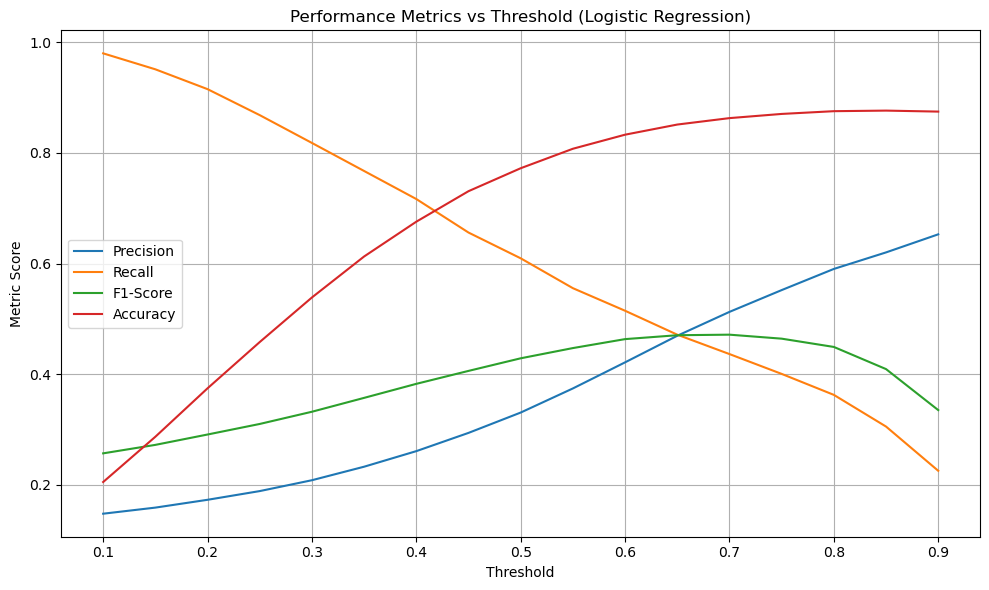


[Threshold = 0.6]
Accuracy: 0.8328228835596648
Precision: 0.42139001349527666
Recall: 0.5146271116604862
F1 Score: 0.46336486737154514
Confusion Matrix:
 [[13163  1715]
 [ 1178  1249]]


In [21]:
#Logistic Regression Training with threshold tuning
# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin özelliği (TF-IDF uygulanacak)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler (genre, type, title)
X_categorical = imdb[["type"]].fillna("unknown") #genre encodelu gerek yok

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF (description)
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal veriyi standardize et
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik veriyi one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Tüm özellikleri birleştir
X_full = hstack([
    X_text,                            # TF-IDF description
    csr_matrix(X_numeric_scaled),      # duration, year, votes, rating
    X_categorical_encoded,             # one-hot type, title, 
    csr_matrix(X_genres.values)        # genre flags (binary)
])

# 11. Eğitim/test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. Logistic Regression modeli
model = LogisticRegression(max_iter=1000 , class_weight = 'balanced')
model.fit(X_train, y_train)

# Varsayılan threshold ile tahmin
y_pred = model.predict(X_test)

# Performans metrikleri
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Olasılıklar (class 1 için)
y_proba = model.predict_proba(X_test)[:, 1]

# Threshold değerleri
thresholds = np.arange(0.1, 0.91, 0.05)

# Metrik listeleri
precisions = []
recalls = []
f1_scores = []
accuracies = []

# Her threshold için skorları hesapla
for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))
    accuracies.append(accuracy_score(y_test, y_pred_thresh))

# Çizim
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1-Score")
plt.plot(thresholds, accuracies, label="Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Metric Score")
plt.title("Performance Metrics vs Threshold (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Generalizes better
# Manuel threshold değeri 
custom_threshold = 0.60
y_pred_manual = (y_proba >= custom_threshold).astype(int)

# Raporlama
print(f"\n[Threshold = {custom_threshold}]")
print("Accuracy:", accuracy_score(y_test, y_pred_manual))
print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))
print("F1 Score:", f1_score(y_test, y_pred_manual))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_manual))

In [27]:
#SVM Model training linear SVC C = 1

from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import pandas as pd

# 1. Veriyi oku
imdb = pd.read_csv("./processed_datasets/imdb_with_platforms.csv")

# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin (description)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler
X_categorical = imdb[["type"]].fillna("unknown")

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF vektörleştirme
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal verileri ölçekleme
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik verileri one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Özellikleri birleştir
X_full = hstack([
    X_text,
    csr_matrix(X_numeric_scaled),
    X_categorical_encoded,
    csr_matrix(X_genres.values)
])

# 11. Eğitim / test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. LinearSVC modeli(#linear kernel cok uzun surdu)
svm_model = LinearSVC( 
    C=1,               
    class_weight="balanced",
    random_state=42,
    max_iter=15000  # convergence uyarısı alırsan artırabilirsin - 10000 verdi.
)

# 13. Modeli eğit
svm_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = svm_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.7457382259462583

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84     14878
           1       0.30      0.60      0.40      2427

    accuracy                           0.75     17305
   macro avg       0.61      0.68      0.62     17305
weighted avg       0.83      0.75      0.78     17305

Confusion Matrix:
 [[11450  3428]
 [  972  1455]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [11]:
#SVM Model training linear SVC C = 1 classweights manual

from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import pandas as pd

# 1. Veriyi oku
imdb = pd.read_csv("./processed_datasets/imdb_with_platforms.csv")

# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin (description)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler
X_categorical = imdb[["type"]].fillna("unknown")

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF vektörleştirme
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal verileri ölçekleme
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik verileri one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Özellikleri birleştir
X_full = hstack([
    X_text,
    csr_matrix(X_numeric_scaled),
    X_categorical_encoded,
    csr_matrix(X_genres.values)
])

# 11. Eğitim / test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. LinearSVC modeli(#linear kernel cok uzun surdu)
svm_model = LinearSVC( 
    C=1,              
    class_weight={0: 1, 1: 8}, #class weight manual (balanced tercih edilir.)
    random_state=42,
    max_iter=15000  # convergence uyarısı alırsan artırabilirsin - 10000 verdi.
)

# 13. Modeli eğit
svm_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = svm_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.6960993932389483

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80     14878
           1       0.26      0.65      0.38      2427

    accuracy                           0.70     17305
   macro avg       0.59      0.68      0.59     17305
weighted avg       0.83      0.70      0.74     17305

Confusion Matrix:
 [[10463  4415]
 [  844  1583]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [49]:
# 12. LinearSVC modeli with C = 0.1 classweights balanced

svm_model = LinearSVC( 
    C=0.1,               #class 1 arttirmak icin 1 den 0.1 e cekildi.
    class_weight="balanced",
    random_state=42,
    max_iter=15000  # convergence uyarısı alırsan artırabilirsin - 10000 verdi.
)

# 13. Modeli eğit
svm_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = svm_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.8818260618318405

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93     14878
           1       0.58      0.60      0.59      2427

    accuracy                           0.88     17305
   macro avg       0.75      0.76      0.76     17305
weighted avg       0.88      0.88      0.88     17305

Confusion Matrix:
 [[13812  1066]
 [  979  1448]]


In [33]:
#XGboost Model Training classweight = balanced

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

# 1. Veriyi oku
imdb = pd.read_csv("./processed_datasets/imdb_with_platforms.csv")

# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin (description)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler (title dahil — istersen çıkarabilirsin)
X_categorical = imdb[["type"]].fillna("unknown")

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF vektörleştirme
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal verileri ölçekleme
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik verileri one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Özellikleri birleştir
X_full = hstack([
    X_text,
    csr_matrix(X_numeric_scaled),
    X_categorical_encoded,
    csr_matrix(X_genres.values)
]).tocsr()  # XGBoost sparse CSR formatını destekler

# 11. Eğitim / test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. XGBoost modeli
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),  # class_weight = balanced
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

# 13. Modeli eğit
xgb_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = xgb_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:43:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8012135221034383

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88     14878
           1       0.38      0.68      0.49      2427

    accuracy                           0.80     17305
   macro avg       0.66      0.75      0.68     17305
weighted avg       0.86      0.80      0.82     17305

Confusion Matrix:
 [[12212  2666]
 [  774  1653]]


In [45]:
# Class sayıları verisetine uyumlu
neg = 80000
pos = 10000
weight = neg / pos  

# Model tanımı
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    scale_pos_weight=weight,
    n_estimators=200, #  300 ,400 denendi
    max_depth=2,  # 2 3 4 6 8 denendi
    learning_rate=0.1,
    random_state=42
)

# 13. Modeli eğit
xgb_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = xgb_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:54:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7543484542039873

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.76      0.84     14878
           1       0.33      0.74      0.46      2427

    accuracy                           0.75     17305
   macro avg       0.64      0.75      0.65     17305
weighted avg       0.86      0.75      0.79     17305

Confusion Matrix:
 [[11268  3610]
 [  641  1786]]
